# Modèle 3 Aiguilleur avec détection d'images non supportées

In [3]:
import os
import random
import shutil
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import splitfolders

from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (BatchNormalization, Dense,
                                     Dropout, Flatten, Input)
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

### 1. Construire le dataset 3 classes

In [4]:
DATASET_POUMONS = '../data_sources/covid-19_radiography_dataset'
DATASET_CERVEAU = '../data_sources/brain_tumor_mri'
DATASET_CT = '../data_sources/Data'

DATASET_TYPE_IMAGE = '../data/type_image_dataset_v2'
N_PAR_CLASSE = 2500          
N_AUTRE_CT = 1250           
N_AUTRE_NON_MEDICAL = 1250   

for classe in ['Radiographie', 'IRM', 'Autre']:
    os.makedirs(os.path.join(DATASET_TYPE_IMAGE, classe), exist_ok=True)

In [5]:
def echantillonner(dataset_racine, dossier_cible, n, seed=SEED):
    toutes_images = glob(os.path.join(dataset_racine, '**', '*'), recursive=True)
    toutes_images = [f for f in toutes_images if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.seed(seed)
    echantillon = random.sample(toutes_images, min(n, len(toutes_images)))
    for chemin in echantillon:
        shutil.copy(chemin, os.path.join(dossier_cible, os.path.basename(chemin)))
    return len(echantillon)

n_radio = echantillonner(DATASET_POUMONS, os.path.join(DATASET_TYPE_IMAGE, 'Radiographie'), N_PAR_CLASSE)
n_irm = echantillonner(DATASET_CERVEAU, os.path.join(DATASET_TYPE_IMAGE, 'IRM'), N_PAR_CLASSE)
n_ct = echantillonner(DATASET_CT, os.path.join(DATASET_TYPE_IMAGE, 'Autre'), N_AUTRE_CT)

print(f"Radiographie : {n_radio} images")
print(f"IRM          : {n_irm} images")
print(f"Autre (CT)   : {n_ct} images")

Radiographie : 2500 images
IRM          : 2500 images
Autre (CT)   : 1000 images


In [6]:
(x_train, _), (x_test, _) = cifar10.load_data()
toutes_images_cifar = np.concatenate([x_train, x_test], axis=0)

random.seed(SEED)
indices = random.sample(range(len(toutes_images_cifar)), N_AUTRE_NON_MEDICAL)

dossier_autre = os.path.join(DATASET_TYPE_IMAGE, 'Autre')
for i, idx in enumerate(indices):
    img = Image.fromarray(toutes_images_cifar[idx])
    img.save(os.path.join(dossier_autre, f'cifar_{i}.png'))

n_autre_total = len(os.listdir(dossier_autre))
print(f"Autre (total, CT + non-médical) : {n_autre_total} images")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1644s 10us/step
Autre (total, CT + non-médical) : 2054 images


### 2. Explorer le dataset construit

Autre: 2054
IRM: 2500
Radiographie: 2500


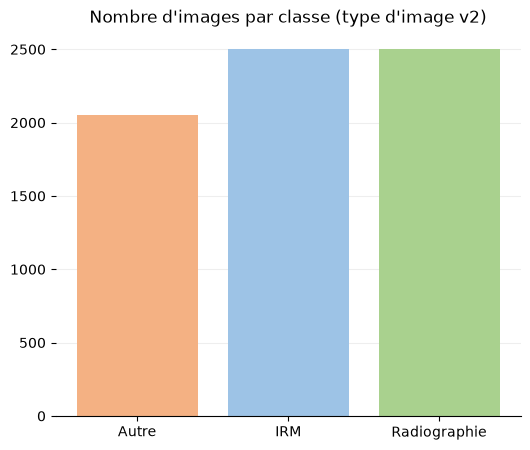

In [7]:
dir_list = os.listdir(DATASET_TYPE_IMAGE)
num_of_images = [len(os.listdir(os.path.join(DATASET_TYPE_IMAGE, d))) for d in dir_list]
for d, n in zip(dir_list, num_of_images):
    print(f'{d}: {n}')

colors = ['#f4b183', '#9dc3e6', '#a9d18e']
fig, ax = plt.subplots(facecolor='white', figsize=(6, 5))
ax.bar(np.arange(len(dir_list)), num_of_images, color=colors)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)
plt.xticks(np.arange(len(dir_list)), dir_list)
plt.title("Nombre d'images par classe (type d'image v2)")
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/type_image_v2_bar_chart.png', dpi=200)
plt.show()

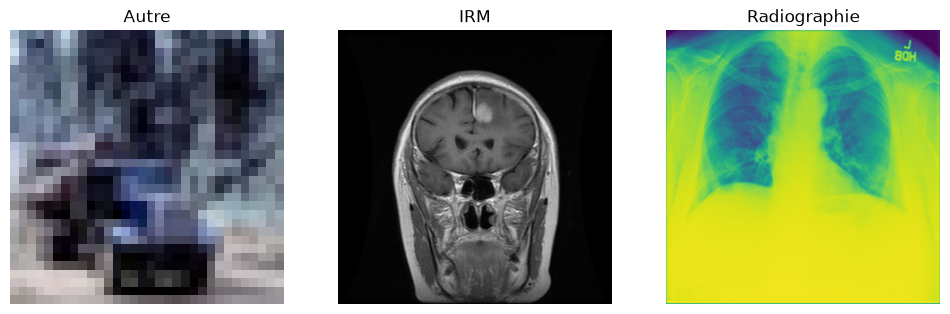

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, classe in zip(axes, dir_list):
    chemin = random.choice(glob(os.path.join(DATASET_TYPE_IMAGE, classe, '*')))
    ax.imshow(Image.open(chemin))
    ax.set_title(classe)
    ax.axis('off')
plt.savefig('figures/type_image_v2_examples.png', dpi=200)
plt.show()

### 3. Split train / val / test

In [9]:
OUTPUT_PATH = '../data/type_image_dataset_v2_split'
if not os.path.exists(OUTPUT_PATH):
    splitfolders.ratio(DATASET_TYPE_IMAGE, OUTPUT_PATH, seed=SEED, ratio=(.7, .1, .2))

Copying files: 7054 files [00:16, 437.49 files/s]


In [10]:
IMG_DIMS = 224
TARGET_SIZE = (IMG_DIMS, IMG_DIMS)
COLOR_MODE = 'rgb'
CLASS_MODE = 'categorical'
BATCH_SIZE = 32

In [11]:
TRAIN_PATH = os.path.join(OUTPUT_PATH, 'train')
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.9, 1.1],
    zoom_range=[0.9, 1.1],
    horizontal_flip=True)
train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=TARGET_SIZE, color_mode=COLOR_MODE,
    class_mode=CLASS_MODE, batch_size=BATCH_SIZE, seed=SEED)

Found 4937 images belonging to 3 classes.


In [12]:
VAL_PATH = os.path.join(OUTPUT_PATH, 'val')
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = val_datagen.flow_from_directory(
    VAL_PATH, target_size=TARGET_SIZE, color_mode=COLOR_MODE,
    class_mode=CLASS_MODE, batch_size=BATCH_SIZE, seed=SEED)

Found 705 images belonging to 3 classes.


In [13]:
TEST_PATH = os.path.join(OUTPUT_PATH, 'test')
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH, target_size=TARGET_SIZE, color_mode=COLOR_MODE,
    class_mode=CLASS_MODE, batch_size=BATCH_SIZE, shuffle=False, seed=SEED)

print(train_gen.class_indices)

Found 1412 images belonging to 3 classes.
{'Autre': 0, 'IRM': 1, 'Radiographie': 2}


### 4. Construire le modèle (toujours DenseNet121, sortie à 3 classes cette fois)

In [14]:
base_model = DenseNet121(
    include_top=False, weights='imagenet',
    input_tensor=Input(shape=(IMG_DIMS, IMG_DIMS, 3)),
    input_shape=(IMG_DIMS, IMG_DIMS, 3))

for layer in base_model.layers:
    layer.trainable = False

In [15]:
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50176)          │       200,704 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    51,381,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,282,499 (226.14 MB)

 Trainable params: 52,141,571 (198.90 MB)

 Non-trainable params: 7,140,928 (27.24 MB)

### 5. Entraîner le modèle

In [16]:
EPOCHS = 8
ETA = 0.0001
METRICS = ['categorical_accuracy', Precision(), Recall()]

model.compile(optimizer=Adam(ETA), loss='categorical_crossentropy', metrics=METRICS)

def scheduler(epoch):
    return ETA * 0.1 if epoch > 5 else ETA
callback = LearningRateScheduler(scheduler)

In [17]:
history = model.fit(train_gen,
                    epochs=EPOCHS,
                    callbacks=callback,
                    validation_data=val_gen)

Epoch 1/8
155/155 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - categorical_accuracy: 0.9874 - loss: 0.0383 - precision: 0.9904 - recall: 0.9854 - val_categorical_accuracy: 1.0000 - val_loss: 4.2222e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/8
155/155 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - categorical_accuracy: 0.9998 - loss: 0.0038 - precision: 0.9998 - recall: 0.9998 - val_categorical_accuracy: 1.0000 - val_loss: 1.9882e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/8
155/155 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - categorical_accuracy: 1.0000 - loss: 0.0014 - precision: 1.0000 - recall: 1.0000 - val_categorical_accuracy: 1.0000 - val_loss: 5.2650e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/8
155/155 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - categorical_accuracy: 0.9998 - loss: 0.0013 - precision: 0.9998 - recall: 0.9998 - val_categorical_accuracy: 1.0000 - val_loss: 3.5344e-05 - val_pre

### 6. Visualiser l'entraînement

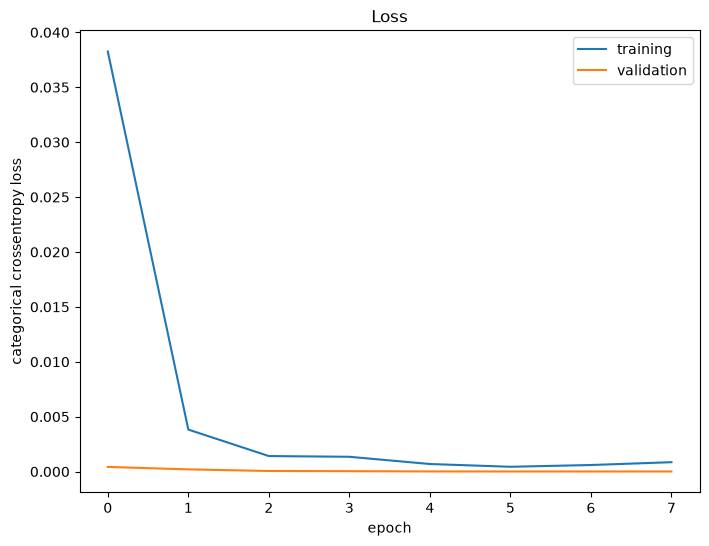

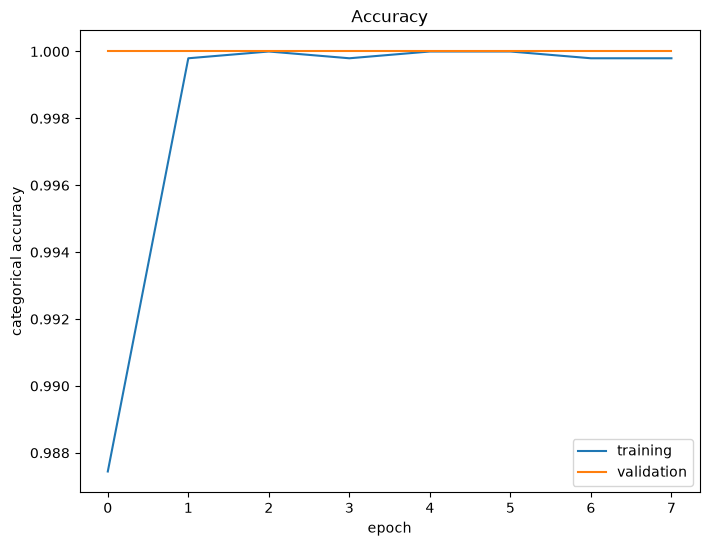

In [18]:
def plot_metric_history(metric, val_metric, y_label, title):
    plt.figure(facecolor='white', figsize=(8, 6))
    plt.plot(history.history[metric])
    plt.plot(history.history[val_metric])
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.title(title)
    plt.legend(['training', 'validation'])
    if not os.path.exists('figures'):
        os.makedirs('figures')
    plt.savefig('figures/type_image_v2_' + y_label + '.png', dpi=200)
    plt.show()

plot_metric_history('loss', 'val_loss', 'categorical crossentropy loss', 'Loss')
plot_metric_history('categorical_accuracy', 'val_categorical_accuracy', 'categorical accuracy', 'Accuracy')

### 7. Évaluer sur le jeu de test

In [19]:
result = model.evaluate(test_gen)
print(dict(zip(model.metrics_names, result)))

predictions = model.predict(test_gen)
y_true = test_gen.labels
y_pred = np.argmax(predictions, axis=1)
noms_classes = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=noms_classes))

45/45 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - categorical_accuracy: 1.0000 - loss: 6.2423e-05 - precision: 1.0000 - recall: 1.0000
{'loss': 6.24227977823466e-05, 'compile_metrics': 1.0}
45/45 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step
              precision    recall  f1-score   support

       Autre       1.00      1.00      1.00       412
         IRM       1.00      1.00      1.00       500
Radiographie       1.00      1.00      1.00       500

    accuracy                           1.00      1412
   macro avg       1.00      1.00      1.00      1412
weighted avg       1.00      1.00      1.00      1412



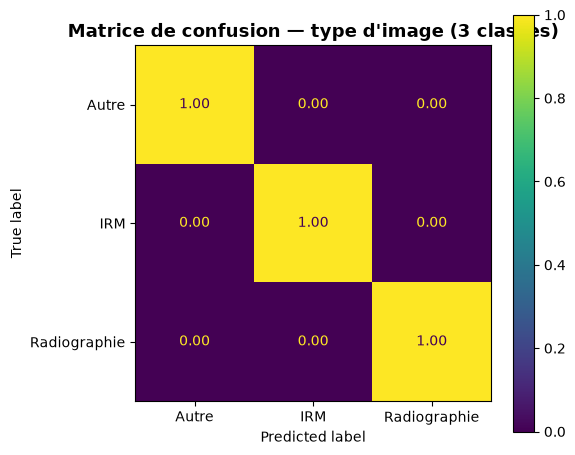

In [20]:
fig, ax = plt.subplots(facecolor='white', figsize=(6, 5), dpi=100)
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=noms_classes,
    include_values=True, normalize='pred', values_format='.2f',
    cmap='viridis', ax=ax)
plt.title("Matrice de confusion — type d'image (3 classes)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/type_image_v2_confusion_matrix.png', dpi=200)
plt.show()

### 8. Sauvegarder le modèle

In [21]:
os.makedirs('../models', exist_ok=True)
model.save('../models/type_image_classification_model.keras')

with open('../models/type_image_classes.txt', 'w') as f:
    f.write('\n'.join(noms_classes))

print("Modèle sauvegardé : ../models/type_image_classification_model.keras")
print("Classes :", noms_classes)

Modèle sauvegardé : ../models/type_image_classification_model.keras
Classes : ['Autre', 'IRM', 'Radiographie']
